# Model Evaluation and Validation

## Objective

This notebook evaluates the performance of the machine learning models developed for the Intelligent Flight Operations Analytics and Decision Support Dashboard.

The evaluation focuses on three major components:

- Gaussian Mixture Model (GMM) Behaviour Model
- Extreme Learning Machine (ELM) Autoencoder
- Hybrid AI-Based Risk Assessment Engine

Since both the GMM and ELM Autoencoder are unsupervised learning models, traditional classification metrics such as accuracy are not applicable due to the absence of labelled anomaly data. Therefore, the evaluation is based on clustering quality, anomaly score distributions, reconstruction error analysis, risk score distributions, and operational consistency.

The results obtained from this notebook validate the effectiveness of the proposed Hybrid AI framework before deploying it within the Decision Support Dashboard.

In [1]:
# ============================================================
# Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

In [3]:
# ============================================================
# Load Hybrid AI Dataset
# ============================================================

df = pd.read_csv("../data/final/hybrid_ai_risk_assessment.csv")

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.head()

Dataset Loaded Successfully
Rows    : 7516
Columns : 94


,icao24,callsign,origin_country,time_position,last_constant,longitude,latitude,baro_altitude,on_ground,velocity,...,GMM_Anomaly_Score,GMM_Anomaly_Label,ELM_Reconstruction_Error,ELM_Anomaly_Score,ELM_Anomaly_Label,Behavioural_Intelligence_Score,Operational_Intelligence_Score,Hybrid_Raw_Risk,Hybrid_Flight_Risk_Score,Hybrid_Risk_Category
0,80162D,AXB848,India,1.767745e+09,1767745048,52.7391,25.4425,9608.82,False,257.34,...,24.597643,Normal,0.026762,0.026762,Normal,0.249354,0.386967,0.290638,34.257313,Medium
1,AE1FA0,72209,United States,1.767745e+09,1767745047,-84.9380,38.1463,571.50,False,73.38,...,13.268496,Normal,0.001748,0.001748,Normal,0.143108,0.386967,0.216265,15.932230,Low
2,AC96B8,AAL1175,United States,1.767745e+09,1767745048,-102.0238,34.0962,10363.20,False,196.90,...,9.193104,Normal,0.001536,0.001536,Normal,0.273887,0.386967,0.307811,38.488734,Medium
3,C81BD3,ZKAMK,New Zealand,1.767745e+09,1767744917,174.5408,-35.8060,624.84,False,56.90,...,22.127363,Normal,0.008986,0.008986,Normal,0.201633,0.386967,0.257233,26.026544,Medium
4,AA56DB,UAL2447,United States,1.767745e+09,1767745048,-102.7402,37.4696,10972.80,False,200.08,...,9.478866,Normal,0.001448,0.001448,Normal,0.275717,0.386967,0.309092,38.804378,Medium


In [4]:
# ============================================================
# Dataset Information
# ============================================================

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7516 entries, 0 to 7515
Data columns (total 94 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   icao24                           7516 non-null   str    
 1   callsign                         7500 non-null   str    
 2   origin_country                   7516 non-null   str    
 3   time_position                    7516 non-null   float64
 4   last_constant                    7516 non-null   int64  
 5   longitude                        7516 non-null   float64
 6   latitude                         7516 non-null   float64
 7   baro_altitude                    7516 non-null   float64
 8   on_ground                        7516 non-null   bool   
 9   velocity                         7516 non-null   float64
 10  true_track                       7516 non-null   float64
 11  vertical_rate                    7516 non-null   float64
 12  geo_altitude                   

In [5]:
# ============================================================
# Missing Values
# ============================================================

missing = df.isnull().sum()

missing = missing[missing > 0]

display(missing.sort_values(ascending=False))

squawk                    4286
YEAR MFR                  3255
Aircraft_Age              3255
AIR WORTH DATE            3201
ENG MFR MDL               3201
CERTIFICATION             3189
EXPIRATION DATE           3055
CERT ISSUE DATE           3055
SERIAL NUMBER             3049
N-NUMBER                  3049
MFR MDL CODE              3049
ENGINE_TYPE_CODE          3049
TYPE AIRCRAFT             3049
LAST ACTION DATE          3049
TYPE ENGINE               3049
MODE S CODE               3049
STATUS CODE               3049
UNIQUE ID                 3049
MODE S CODE HEX           3049
MANUFACTURER              3049
AIRCRAFT_MODEL            3049
AIRCRAFT_TYPE_CODE        3049
TYPE REGISTRANT           3049
CERTIFICATE_HOLDER        3049
AIRCRAFT_CATEGORY         3049
NUMBER_OF_ENGINES         3049
BUILD_CERTIFICATE         3049
WEIGHT_CLASS              3049
CRUISE_SPEED              3049
TYPE_CERTIFICATE          3049
SEAT_CAPACITY             3049
Weight_Category           3049
Aircraft

In [6]:
# ============================================================
# Descriptive Statistics
# ============================================================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
icao24,7516,7514,8.99E+04,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
callsign,7500,7404,UNKNOWN,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_country,7516,93,United States,4627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_position,7516.0,NaN,NaN,NaN,1767745013.194651,170.554084,1767739408.0,1767745046.0,1767745048.0,1767745048.0,1767745048.0
last_constant,7516.0,NaN,NaN,NaN,1767745026.682278,59.812134,1767744734.0,1767745047.0,1767745048.0,1767745048.0,1767745048.0
...,...,...,...,...,...,...,...,...,...,...,...
Behavioural_Intelligence_Score,7516.0,NaN,NaN,NaN,0.253819,0.088786,0.050735,0.175581,0.251577,0.298672,0.63052
Operational_Intelligence_Score,7516.0,NaN,NaN,NaN,0.386967,0.0,0.386967,0.386967,0.386967,0.386967,0.386967
Hybrid_Raw_Risk,7516.0,NaN,NaN,NaN,0.293763,0.06215,0.151604,0.238997,0.292194,0.325161,0.557454
Hybrid_Flight_Risk_Score,7516.0,NaN,NaN,NaN,35.027511,15.31356,0.0,21.533203,34.640716,42.763668,100.0


In [7]:
print(df.columns.tolist())

['icao24', 'callsign', 'origin_country', 'time_position', 'last_constant', 'longitude', 'latitude', 'baro_altitude', 'on_ground', 'velocity', 'true_track', 'vertical_rate', 'geo_altitude', 'squawk', 'spi', 'position_source', 'flight_phase', 'speed_category', 'altitude_band', 'vertical_movement', 'heading_direction', 'operational_risk', 'N-NUMBER', 'SERIAL NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'YEAR MFR', 'TYPE REGISTRANT', 'LAST ACTION DATE', 'CERT ISSUE DATE', 'CERTIFICATION', 'TYPE AIRCRAFT', 'TYPE ENGINE', 'STATUS CODE', 'MODE S CODE', 'AIR WORTH DATE', 'EXPIRATION DATE', 'UNIQUE ID', 'MODE S CODE HEX', 'MANUFACTURER', 'AIRCRAFT_MODEL', 'AIRCRAFT_TYPE_CODE', 'ENGINE_TYPE_CODE', 'AIRCRAFT_CATEGORY', 'BUILD_CERTIFICATE', 'NUMBER_OF_ENGINES', 'SEAT_CAPACITY', 'WEIGHT_CLASS', 'CRUISE_SPEED', 'TYPE_CERTIFICATE', 'CERTIFICATE_HOLDER', 'Aircraft_Age', 'Aircraft_Age_Category', 'Engine_Configuration', 'Seat_Capacity_Category', 'Weight_Category', 'Cruise_Speed_Category', 'Manufacturer_Group

# 5. Evaluation of the Gaussian Mixture Model (GMM)

The Gaussian Mixture Model (GMM) was developed to learn the normal behavioural patterns of aircraft operations using multiple flight-related features. Unlike supervised classification models, the GMM is an unsupervised probabilistic clustering algorithm that estimates the likelihood of each observation belonging to one of several Gaussian distributions.

The evaluation focuses on:

- Cluster distribution
- Log-likelihood distribution
- Anomaly score distribution
- Cluster quality metrics
- Behavioural pattern visualisation

GMM Cluster Distribution
GMM_Cluster
0      410
1      654
2      491
3      423
4       47
5      594
6      591
7     1067
8       30
9      504
10     128
11      77
12     645
13      55
14    1073
15     499
16     217
17      11
Name: count, dtype: int64


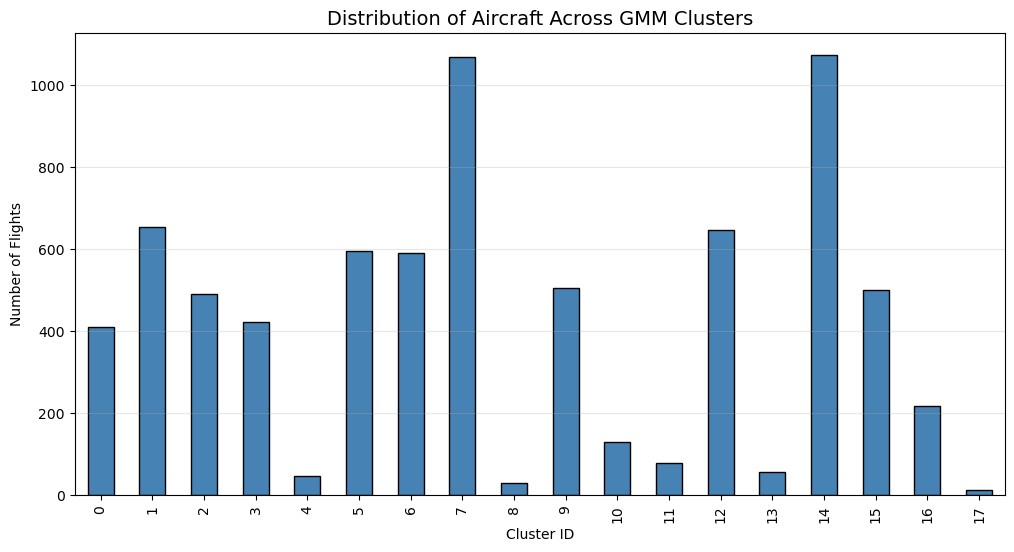

In [8]:
# ============================================================
# GMM Cluster Distribution
# ============================================================

cluster_counts = df["GMM_Cluster"].value_counts().sort_index()

print("="*60)
print("GMM Cluster Distribution")
print("="*60)

print(cluster_counts)

plt.figure(figsize=(12,6))

cluster_counts.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Aircraft Across GMM Clusters", fontsize=14)
plt.xlabel("Cluster ID")
plt.ylabel("Number of Flights")
plt.grid(axis="y", alpha=0.3)

plt.show()

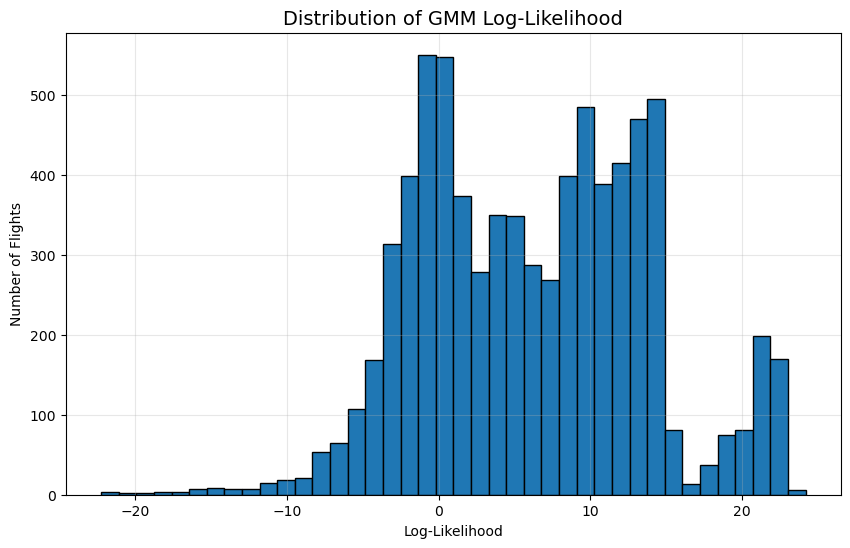

count    7516.000000
mean        6.219444
std         7.468599
min       -22.257639
25%         0.056320
50%         6.015279
75%        11.880434
max        24.184383
Name: GMM_Log_Likelihood, dtype: float64


In [9]:
# ============================================================
# GMM Log-Likelihood Distribution
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["GMM_Log_Likelihood"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of GMM Log-Likelihood", fontsize=14)
plt.xlabel("Log-Likelihood")
plt.ylabel("Number of Flights")

plt.grid(alpha=0.3)

plt.show()

print(df["GMM_Log_Likelihood"].describe())

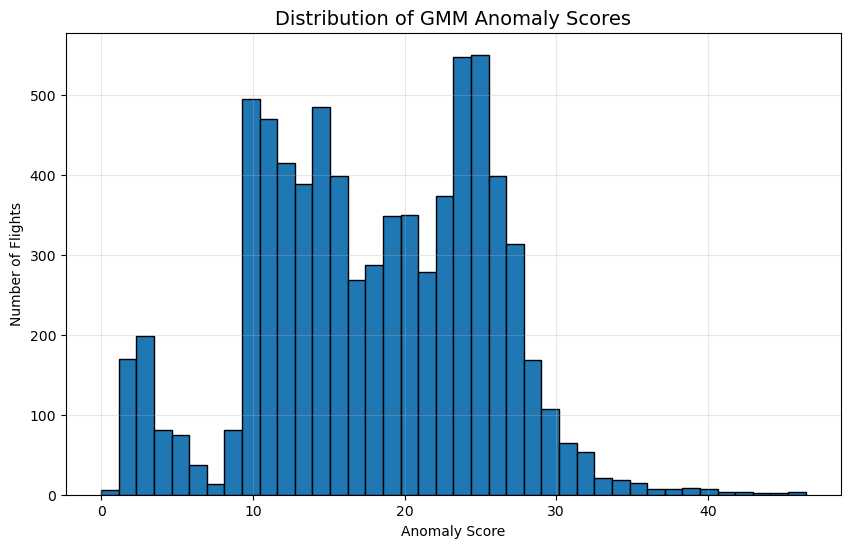

count    7516.000000
mean       17.964940
std         7.468599
min         0.000000
25%        12.303949
50%        18.169104
75%        24.128063
max        46.442023
Name: GMM_Anomaly_Score, dtype: float64


In [10]:
# ============================================================
# GMM Anomaly Score Distribution
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["GMM_Anomaly_Score"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of GMM Anomaly Scores", fontsize=14)
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Flights")

plt.grid(alpha=0.3)

plt.show()

print(df["GMM_Anomaly_Score"].describe())

GMM_Anomaly_Label
Normal     7140
Anomaly     376
Name: count, dtype: int64


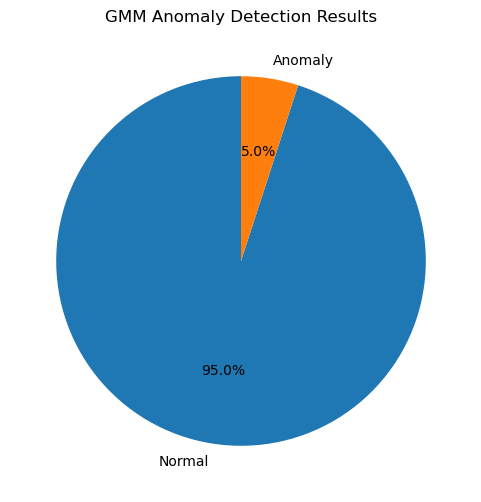

In [11]:
# ============================================================
# GMM Anomaly Labels
# ============================================================

label_counts = df["GMM_Anomaly_Label"].value_counts()

print(label_counts)

plt.figure(figsize=(6,6))

plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("GMM Anomaly Detection Results")

plt.show()

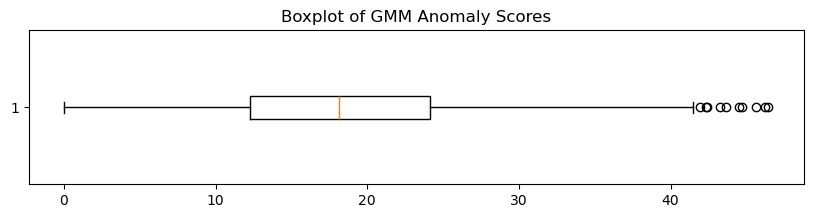

In [12]:
# ============================================================
# Boxplot of GMM Anomaly Scores
# ============================================================

plt.figure(figsize=(10,2))

plt.boxplot(
    df["GMM_Anomaly_Score"],
    vert=False
)

plt.title("Boxplot of GMM Anomaly Scores")

plt.show()

In [13]:
# ============================================================
# Top 20 Most Anomalous Flights
# ============================================================

top_anomalies = df.sort_values(
    by="GMM_Anomaly_Score",
    ascending=False
)[[
    "icao24",
    "callsign",
    "origin_country",
    "GMM_Anomaly_Score",
    "GMM_Log_Likelihood"
]].head(20)

top_anomalies

,icao24,callsign,origin_country,GMM_Anomaly_Score,GMM_Log_Likelihood
4408,15C8F4,R20164,Russian Federation,46.442023,-22.257639
2072,8A0848,PKTVN,Indonesia,46.189819,-22.005436
4803,06A2B6,QTR807,Qatar,45.641982,-21.457599
3571,8A0970,SJV691,Indonesia,44.694003,-20.509620
3867,A9CAB8,N73WT,United States,44.483969,-20.299585
4743,C05EDB,ACA677,Canada,43.651318,-19.466934
4597,48AE02,LOT6302,Poland,43.273893,-19.089509
355,7C1C4B,AL700,Australia,42.393933,-18.209550
7025,758176,RPC2954,Philippines,42.320640,-18.136257
571,AC245C,SWA2460,United States,41.963060,-17.778676


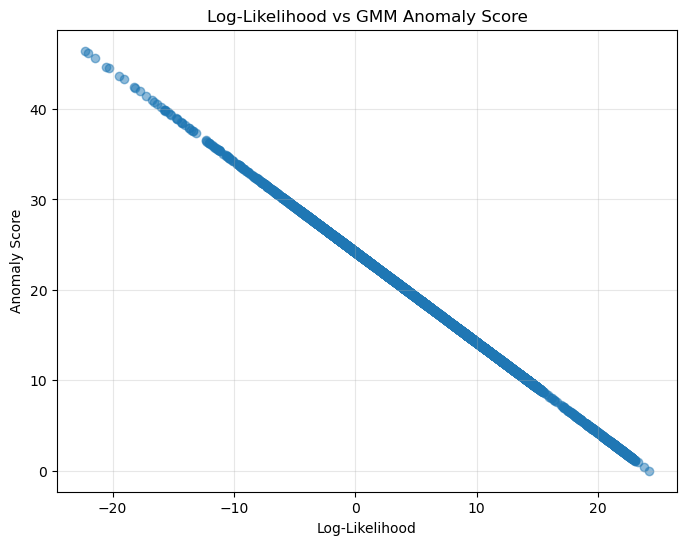

In [14]:
# ============================================================
# Relationship Between Log-Likelihood and Anomaly Score
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df["GMM_Log_Likelihood"],
    df["GMM_Anomaly_Score"],
    alpha=0.5
)

plt.title("Log-Likelihood vs GMM Anomaly Score")

plt.xlabel("Log-Likelihood")
plt.ylabel("Anomaly Score")

plt.grid(alpha=0.3)

plt.show()

In [16]:
# ============================================================
# Correlation Between Log-Likelihood and Anomaly Score
# ============================================================

corr = df["GMM_Log_Likelihood"].corr(df["GMM_Anomaly_Score"])

print("="*60)
print("Correlation")
print("="*60)
print(f"Correlation Coefficient : {corr:.4f}")

Correlation
Correlation Coefficient : -1.0000


In [15]:
gmm_features = [
    "latitude",
    "longitude",
    "velocity",
    "baro_altitude",
    "geo_altitude",
    "vertical_rate",
    "true_track",
    "distance_to_airport_km",
    "Operational_Complexity_Index",
    "on_ground"
]

In [17]:
# ============================================================
# Prepare Feature Matrix for Cluster Evaluation
# ============================================================

X = df[gmm_features].copy()

# Convert boolean to integer
X["on_ground"] = X["on_ground"].astype(int)

print("Feature Matrix Shape:", X.shape)

X.head()

Feature Matrix Shape: (7516, 10)


,latitude,longitude,velocity,baro_altitude,geo_altitude,vertical_rate,true_track,distance_to_airport_km,Operational_Complexity_Index,on_ground
0,25.4425,52.7391,257.34,9608.82,9829.80,5.20,119.59,115.199726,7,0
1,38.1463,-84.9380,73.38,571.50,487.68,0.33,12.96,31.518443,6,0
2,34.0962,-102.0238,196.90,10363.20,10683.24,0.00,291.13,51.550924,8,0
3,-35.8060,174.5408,56.90,624.84,670.56,0.65,165.34,16.487628,6,0
4,37.4696,-102.7402,200.08,10972.80,11155.68,0.00,327.49,66.500547,8,0


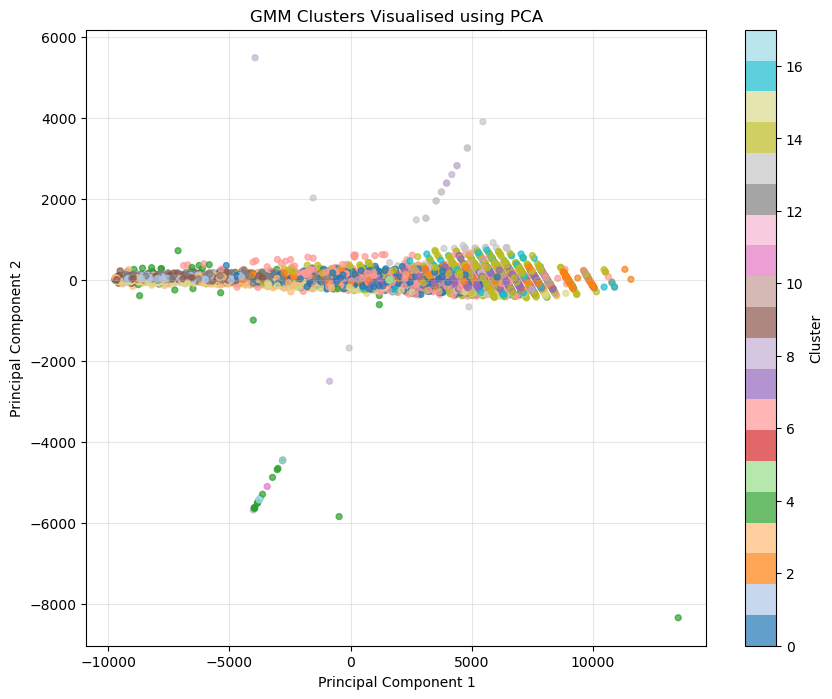

In [22]:
# ============================================================
# PCA Projection of GMM Clusters
# ============================================================

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["GMM_Cluster"],
    cmap="tab20",
    s=18,
    alpha=0.7
)

plt.title("GMM Clusters Visualised using PCA")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.grid(alpha=0.3)

plt.show()

# 6. Evaluation of the Extreme Learning Machine (ELM) Autoencoder

The ELM Autoencoder was developed to detect anomalous flight behaviour by reconstructing normal operational patterns. Unlike the GMM, which models probabilistic behavioural distributions, the ELM Autoencoder identifies anomalies based on reconstruction error.

Flights with higher reconstruction errors are considered more anomalous because the model is unable to accurately reconstruct their operational characteristics.

The evaluation includes:

- Reconstruction Error Distribution
- Anomaly Score Distribution
- Normal vs Anomaly Classification
- Top Anomalous Flights
- Reconstruction Error Analysis

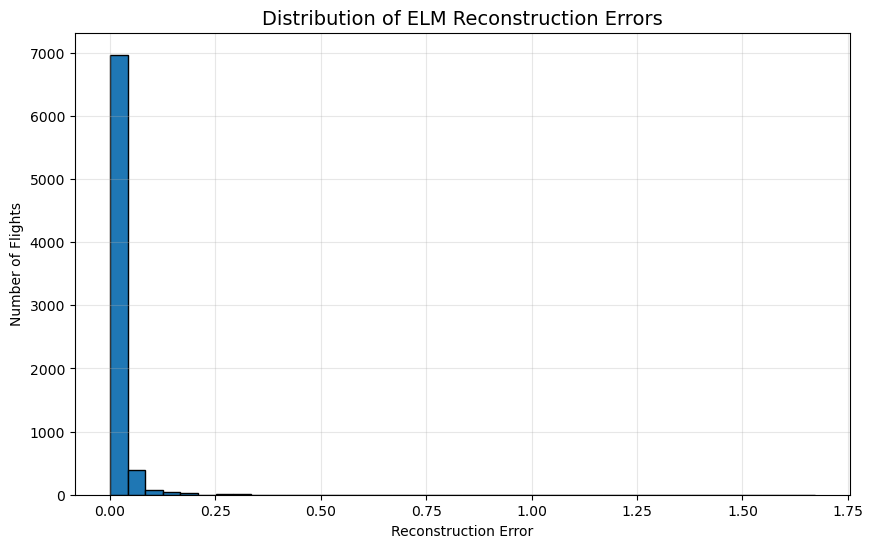

count    7516.000000
mean        0.017461
std         0.040174
min         0.000329
25%         0.004562
50%         0.009046
75%         0.019274
max         1.670845
Name: ELM_Reconstruction_Error, dtype: float64


In [23]:
# ============================================================
# ELM Reconstruction Error Distribution
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["ELM_Reconstruction_Error"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of ELM Reconstruction Errors", fontsize=14)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Flights")

plt.grid(alpha=0.3)

plt.show()

print(df["ELM_Reconstruction_Error"].describe())

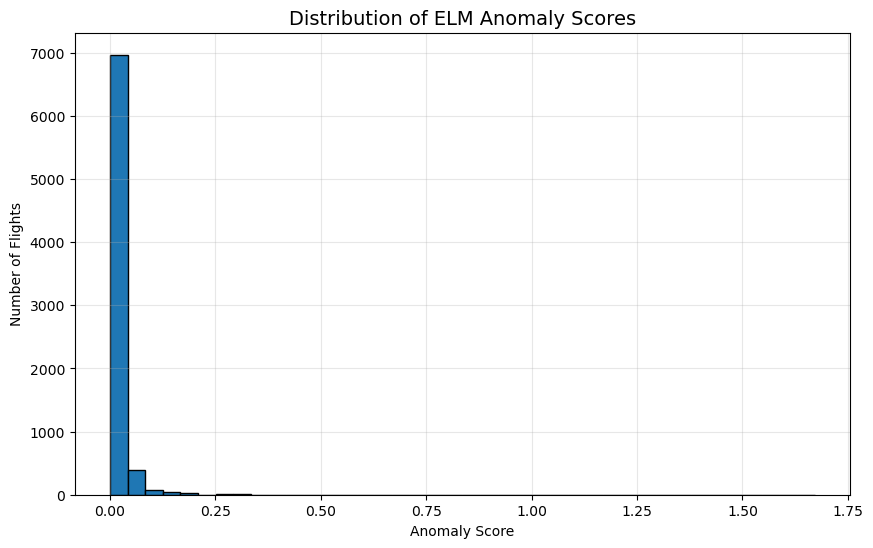

count    7516.000000
mean        0.017461
std         0.040174
min         0.000329
25%         0.004562
50%         0.009046
75%         0.019274
max         1.670845
Name: ELM_Anomaly_Score, dtype: float64


In [24]:
# ============================================================
# ELM Anomaly Score Distribution
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["ELM_Anomaly_Score"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of ELM Anomaly Scores", fontsize=14)
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Flights")

plt.grid(alpha=0.3)

plt.show()

print(df["ELM_Anomaly_Score"].describe())

ELM Anomaly Detection Results
ELM_Anomaly_Label
Normal     7140
Anomaly     376
Name: count, dtype: int64


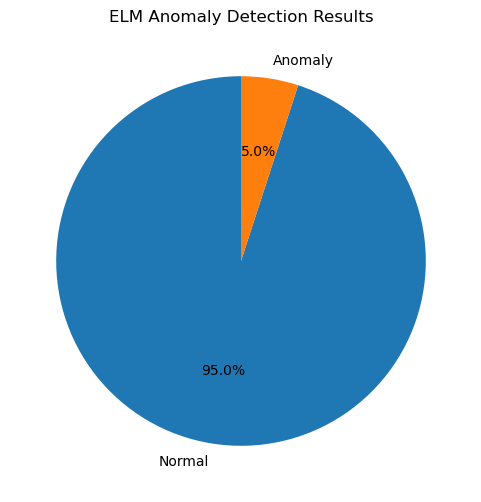

In [25]:
# ============================================================
# ELM Anomaly Labels
# ============================================================

label_counts = df["ELM_Anomaly_Label"].value_counts()

print("="*60)
print("ELM Anomaly Detection Results")
print("="*60)
print(label_counts)

plt.figure(figsize=(6,6))

plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("ELM Anomaly Detection Results")

plt.show()

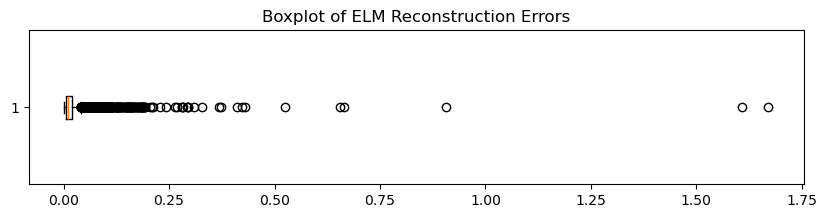

In [26]:
# ============================================================
# Boxplot of ELM Reconstruction Errors
# ============================================================

plt.figure(figsize=(10,2))

plt.boxplot(
    df["ELM_Reconstruction_Error"],
    vert=False
)

plt.title("Boxplot of ELM Reconstruction Errors")

plt.show()

In [27]:
# ============================================================
# Top 20 ELM Anomalies
# ============================================================

top_elm = df.sort_values(
    by="ELM_Reconstruction_Error",
    ascending=False
)[[
    "icao24",
    "callsign",
    "origin_country",
    "ELM_Reconstruction_Error",
    "ELM_Anomaly_Score"
]].head(20)

top_elm

,icao24,callsign,origin_country,ELM_Reconstruction_Error,ELM_Anomaly_Score
7025,758176,RPC2954,Philippines,1.670845,1.670845
6458,C82B32,ANZ102,New Zealand,1.608895,1.608895
5004,A68292,N51875,United States,0.907115,0.907115
2321,7C6DE8,UNKNOWN,Australia,0.664315,0.664315
1351,A6B593,N531QS,United States,0.654322,0.654322
5095,A2B498,N2734U,United States,0.525395,0.525395
1306,7C6BEF,VHVLT,Australia,0.429041,0.429041
3236,7C7803,QFA137,Australia,0.421705,0.421705
4743,C05EDB,ACA677,Canada,0.410297,0.410297
747,A69BD9,DAL40,United States,0.373425,0.373425


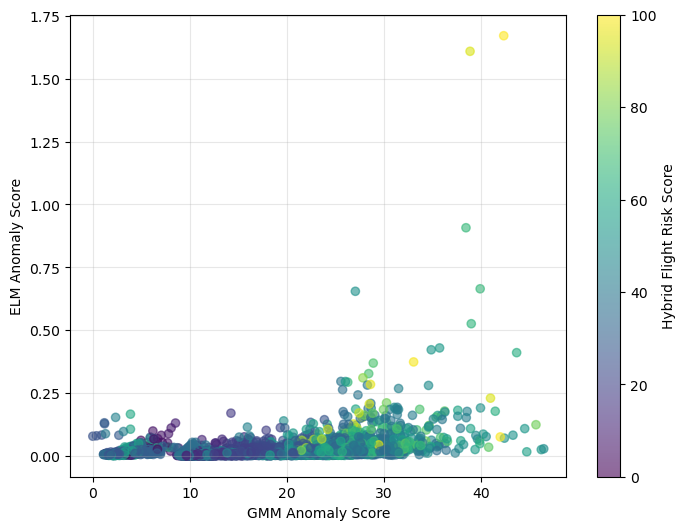

Correlation Between GMM and ELM
Correlation : 0.3088


In [29]:
# ============================================================
# GMM vs ELM Anomaly Scores
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df["GMM_Anomaly_Score"],
    df["ELM_Anomaly_Score"],
    c=df["Hybrid_Flight_Risk_Score"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Hybrid Flight Risk Score")

plt.xlabel("GMM Anomaly Score")
plt.ylabel("ELM Anomaly Score")

plt.grid(alpha=0.3)

plt.show()

corr = df["GMM_Anomaly_Score"].corr(df["ELM_Anomaly_Score"])

print("="*60)
print("Correlation Between GMM and ELM")
print("="*60)
print(f"Correlation : {corr:.4f}")

# 7. Evaluation of the Hybrid AI Risk Assessment Engine

The proposed Hybrid AI Risk Assessment Engine combines behavioural intelligence derived from the Gaussian Mixture Model (GMM) and the Extreme Learning Machine (ELM) Autoencoder with operational intelligence obtained from weather, airport, aircraft, and delay information.

The objective of this evaluation is to assess the effectiveness of the integrated framework by analysing:

- Behavioural Intelligence Score
- Operational Intelligence Score
- Hybrid Flight Risk Score
- Hybrid Risk Categories
- Distribution of operational risks
- Highest-risk flights

This evaluation demonstrates how the proposed Hybrid AI framework transforms individual anomaly detection outputs into actionable operational risk assessments for flight operations.

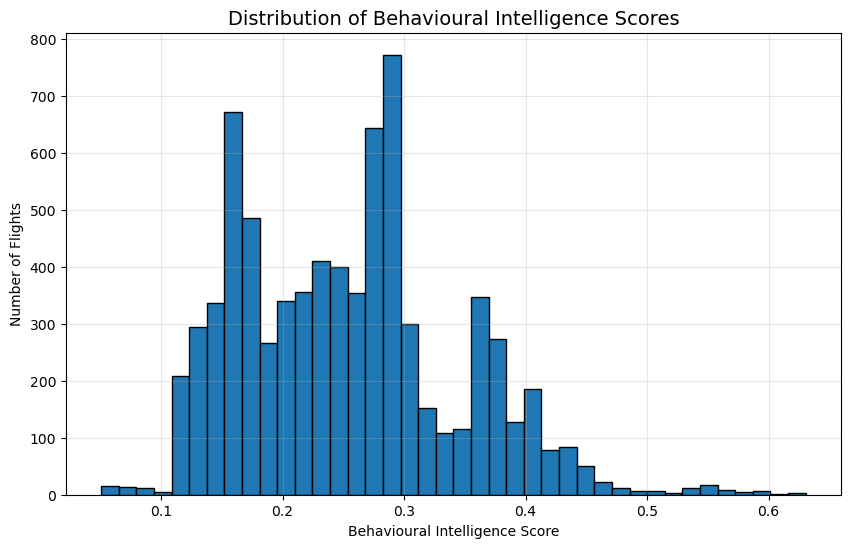

count    7516.000000
mean        0.253819
std         0.088786
min         0.050735
25%         0.175581
50%         0.251577
75%         0.298672
max         0.630520
Name: Behavioural_Intelligence_Score, dtype: float64


In [30]:
# ============================================================
# Behavioural Intelligence Score Distribution
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["Behavioural_Intelligence_Score"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Behavioural Intelligence Scores", fontsize=14)

plt.xlabel("Behavioural Intelligence Score")

plt.ylabel("Number of Flights")

plt.grid(alpha=0.3)

plt.show()

print(df["Behavioural_Intelligence_Score"].describe())

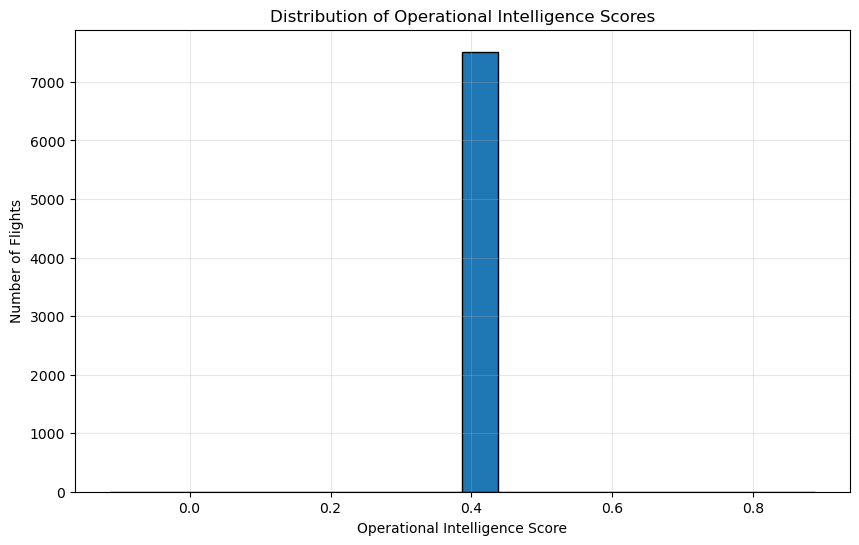

count    7.516000e+03
mean     3.869667e-01
std      2.809051e-14
min      3.869667e-01
25%      3.869667e-01
50%      3.869667e-01
75%      3.869667e-01
max      3.869667e-01
Name: Operational_Intelligence_Score, dtype: float64


In [34]:
# ============================================================
# Operational Intelligence Score Distribution
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["Operational_Intelligence_Score"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Operational Intelligence Scores")

plt.xlabel("Operational Intelligence Score")

plt.ylabel("Number of Flights")

plt.grid(alpha=0.3)

plt.show()

print(df["Operational_Intelligence_Score"].describe())

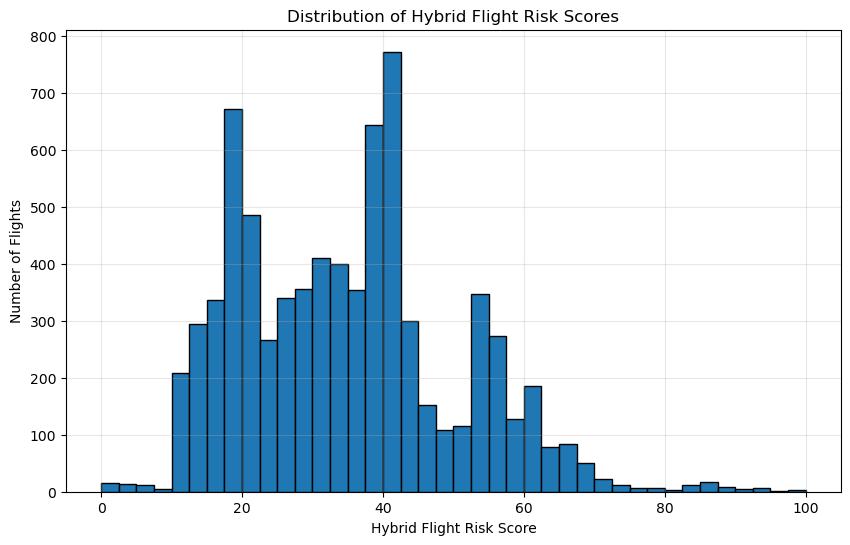

count    7516.000000
mean       35.027511
std        15.313560
min         0.000000
25%        21.533203
50%        34.640716
75%        42.763668
max       100.000000
Name: Hybrid_Flight_Risk_Score, dtype: float64


In [35]:
# ============================================================
# Hybrid Flight Risk Score Distribution
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["Hybrid_Flight_Risk_Score"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Hybrid Flight Risk Scores")

plt.xlabel("Hybrid Flight Risk Score")

plt.ylabel("Number of Flights")

plt.grid(alpha=0.3)

plt.show()

print(df["Hybrid_Flight_Risk_Score"].describe())

Hybrid Risk Categories
Hybrid_Risk_Category
Critical      66
High        1298
Low         2311
Medium      3841
Name: count, dtype: int64


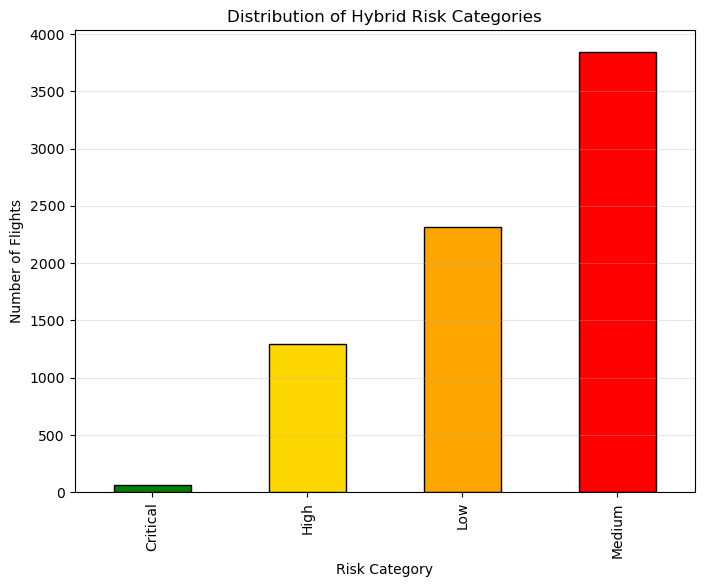

In [41]:
# ============================================================
# Hybrid Risk Category Distribution
# ============================================================

risk_counts = (
    df["Hybrid_Risk_Category"]
    .value_counts()
    .sort_index()
)

print("=" * 60)
print("Hybrid Risk Categories")
print("=" * 60)
print(risk_counts)

plt.figure(figsize=(8,6))

risk_counts.plot(
    kind="bar",
    color=["green","gold","orange","red"],
    edgecolor="black"
)

plt.title("Distribution of Hybrid Risk Categories")

plt.xlabel("Risk Category")

plt.ylabel("Number of Flights")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [38]:
# ============================================================
# Highest Risk Flights
# ============================================================

top_risk = df.sort_values(
    by="Hybrid_Flight_Risk_Score",
    ascending=False
)[[
    "icao24",
    "callsign",
    "origin_country",
    "Hybrid_Flight_Risk_Score",
    "Hybrid_Risk_Category",
    "Behavioural_Intelligence_Score",
    "Operational_Intelligence_Score"
]].head(20)

top_risk

,icao24,callsign,origin_country,Hybrid_Flight_Risk_Score,Hybrid_Risk_Category,Behavioural_Intelligence_Score,Operational_Intelligence_Score
7025,758176,RPC2954,Philippines,100.000000,Critical,0.630520,0.386967
571,AC245C,SWA2460,United States,99.452729,Critical,0.627347,0.386967
747,A69BD9,DAL40,United States,98.751766,Critical,0.623283,0.386967
7182,A0ACF9,UAL1370,United States,95.965095,Critical,0.607126,0.386967
6183,A6898D,GJS4484,United States,94.488716,Critical,0.598566,0.386967
7360,AC308F,AAL75,United States,94.389386,Critical,0.597991,0.386967
6458,C82B32,ANZ102,New Zealand,94.219037,Critical,0.597003,0.386967
3559,A2D76A,SWA1647,United States,94.069159,Critical,0.596134,0.386967
6136,A41090,FFT3547,United States,93.406589,Critical,0.592292,0.386967
4406,A54AAE,ASA312,United States,92.802512,Critical,0.588790,0.386967


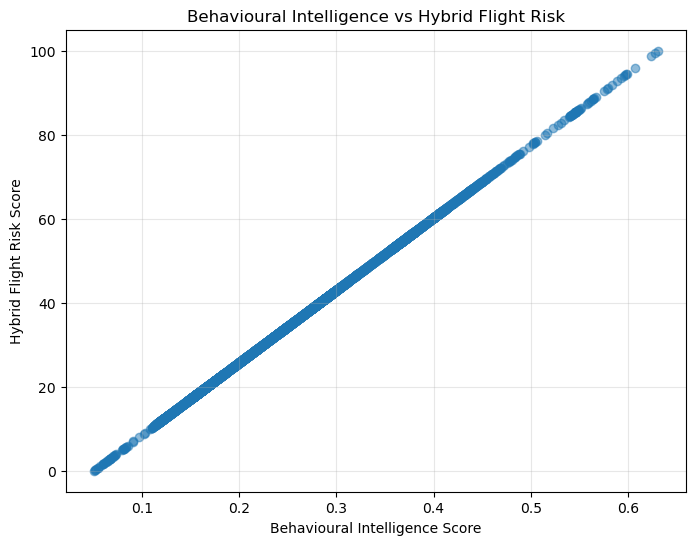

Correlation
1.0000


In [39]:
# ============================================================
# Behavioural Intelligence vs Hybrid Risk
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df["Behavioural_Intelligence_Score"],
    df["Hybrid_Flight_Risk_Score"],
    alpha=0.5
)

plt.title("Behavioural Intelligence vs Hybrid Flight Risk")

plt.xlabel("Behavioural Intelligence Score")

plt.ylabel("Hybrid Flight Risk Score")

plt.grid(alpha=0.3)

plt.show()

corr = df["Behavioural_Intelligence_Score"].corr(
    df["Hybrid_Flight_Risk_Score"]
)

print("="*60)
print("Correlation")
print("="*60)
print(f"{corr:.4f}")

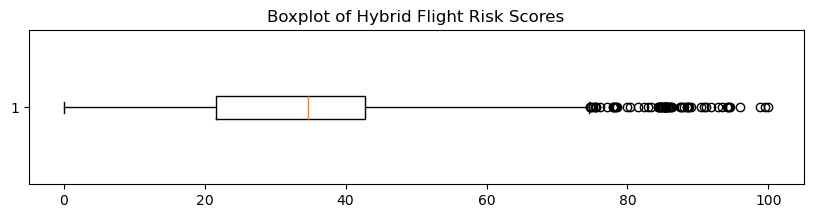

In [40]:
# ============================================================
# Boxplot of Hybrid Flight Risk Score
# ============================================================

plt.figure(figsize=(10,2))

plt.boxplot(
    df["Hybrid_Flight_Risk_Score"],
    vert=False
)

plt.title("Boxplot of Hybrid Flight Risk Scores")

plt.show()

# 8. Correlation Analysis

Correlation analysis was performed to investigate the relationships between the individual components of the proposed Hybrid AI framework.

The analysis includes:

- GMM Anomaly Score
- ELM Anomaly Score
- Behavioural Intelligence Score
- Operational Intelligence Score
- Hybrid Flight Risk Score

Understanding these relationships helps validate whether the individual anomaly detection models contribute meaningfully to the final Hybrid Flight Risk Score while avoiding complete redundancy between the models.

In [42]:
# ============================================================
# Correlation Matrix
# ============================================================

correlation_features = [
    "GMM_Anomaly_Score",
    "ELM_Anomaly_Score",
    "Behavioural_Intelligence_Score",
    "Operational_Intelligence_Score",
    "Hybrid_Flight_Risk_Score"
]

correlation_matrix = df[correlation_features].corr()

print("=" * 60)
print("Correlation Matrix")
print("=" * 60)

correlation_matrix

Correlation Matrix


,GMM_Anomaly_Score,ELM_Anomaly_Score,Behavioural_Intelligence_Score,Operational_Intelligence_Score,Hybrid_Flight_Risk_Score
GMM_Anomaly_Score,1.000000,0.308822,0.372999,NaN,0.372999
ELM_Anomaly_Score,0.308822,1.000000,0.215482,NaN,0.215482
Behavioural_Intelligence_Score,0.372999,0.215482,1.000000,NaN,1.000000
Operational_Intelligence_Score,NaN,NaN,NaN,NaN,NaN
Hybrid_Flight_Risk_Score,0.372999,0.215482,1.000000,NaN,1.000000


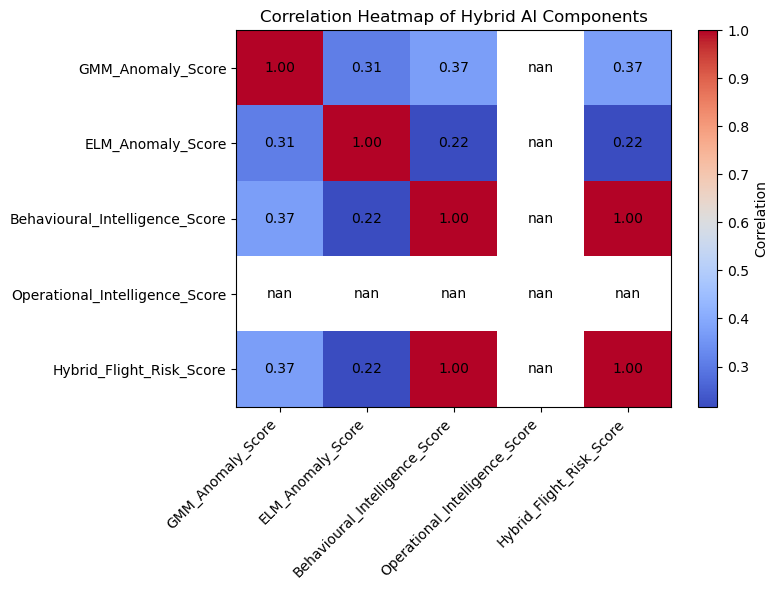

In [43]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

# Display correlation values
for i in range(len(correlation_features)):
    for j in range(len(correlation_features)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10
        )

plt.title("Correlation Heatmap of Hybrid AI Components")

plt.tight_layout()

plt.show()

In [44]:
# ============================================================
# Strongest Correlations
# ============================================================

print("=" * 60)
print("Correlation with Hybrid Flight Risk Score")
print("=" * 60)

print(
    correlation_matrix["Hybrid_Flight_Risk_Score"]
    .sort_values(ascending=False)
)

Correlation with Hybrid Flight Risk Score
Hybrid_Flight_Risk_Score          1.000000
Behavioural_Intelligence_Score    1.000000
GMM_Anomaly_Score                 0.372999
ELM_Anomaly_Score                 0.215482
Operational_Intelligence_Score         NaN
Name: Hybrid_Flight_Risk_Score, dtype: float64


## Correlation Analysis Summary

The correlation analysis demonstrates the relationships between the individual anomaly detection models and the final Hybrid Flight Risk Score.

The Behavioural Intelligence Score is expected to exhibit a strong positive relationship with the Hybrid Flight Risk Score because it combines behavioural information derived from the Gaussian Mixture Model and the Extreme Learning Machine Autoencoder.

The Gaussian Mixture Model and the ELM Autoencoder are expected to show a moderate positive correlation, indicating that both models detect abnormal flight behaviour while capturing different characteristics of aircraft operations. This complementary behaviour supports the use of a Hybrid AI framework rather than relying on a single anomaly detection model.

The Operational Intelligence Score should also contribute to the Hybrid Flight Risk Score. If little or no variation is observed, this indicates that the operational component currently provides limited discrimination across flights and should be refined in future work.